<a href="https://colab.research.google.com/github/emcgeever-husky/Econ3916/blob/main/Project_1/Data_Audit_%26_Forensics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## NJ Minimum Wage Dataset
###Card & Krueger (1994) — *Minimum Wages and Employment: A Case Study of the Fast-Food Industry in New Jersey and Pennsylvania*

410 fast food restaurants surveyed in two waves (before/after NJ raised its minimum wage from $4.25 to $5.05 in April of 1992).

##### Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api

#### Importing the Dataset

In [6]:
# store names before for import

names = [
    'SHEET','CHAIN','CO_OWNED','STATE',                                         # Store ID, chain type, ownership, state (NJ=1, PA=0)
    'SOUTHJ','CENTRALJ','NORTHJ','PA1','PA2','SHORE',                           # Location dummies
    'NCALLS','EMPFT','EMPPT','NMGRS','WAGE_ST','INCTIME','FIRSTINC',            # Wave 1: callbacks, employment counts, wage/raise info
    'BONUS','PCTAFF','MEALS','OPEN','HRSOPEN','PSODA','PFRY','PENTREE',         # Wave 1: benefits, pricing
    'NREGS','NREGS11',                                                          # Wave 1: register counts
    'TYPE2','STATUS2','DATE2','NCALLS2','EMPFT2','EMPPT2','NMGRS2',             # Wave 2: interview type, status, date, employment
    'WAGE_ST2','INCTIME2','FIRSTIN2','SPECIAL2','MEALS2','OPEN2R','HRSOPEN2',   # Wave 2: wage/raise info, benefits
    'PSODA2','PFRY2','PENTREE2','NREGS2','NREGS112'                             # Wave 2: pricing, register counts
]

###  Card and Krueger uses a ASCII file type, so headers and delimiters must be manually added.

In [7]:
df = pd.read_csv('public.dat',
    sep=r'\s+',                             # Regex: split on one or more whitespace characters
    names=names,                            # Apply the names column names list
    na_values='.')                          # '.' == missing values

In [8]:
df # Expected: 410 obs, 46 cols

,SHEET,CHAIN,CO_OWNED,STATE,SOUTHJ,CENTRALJ,NORTHJ,PA1,PA2,SHORE,...,FIRSTIN2,SPECIAL2,MEALS2,OPEN2R,HRSOPEN2,PSODA2,PFRY2,PENTREE2,NREGS2,NREGS112
0,46,1,0,0,0,0,0,1,0,0,...,0.08,1.0,2.0,6.5,16.5,1.03,NaN,0.94,4.0,4.0
1,49,2,0,0,0,0,0,1,0,0,...,0.05,0.0,2.0,10.0,13.0,1.01,0.89,2.35,4.0,4.0
2,506,2,1,0,0,0,0,1,0,0,...,0.25,NaN,1.0,11.0,11.0,0.95,0.74,2.33,4.0,3.0
3,56,4,1,0,0,0,0,1,0,0,...,0.15,0.0,2.0,10.0,12.0,0.92,0.79,0.87,2.0,2.0
4,61,4,1,0,0,0,0,1,0,0,...,0.15,0.0,2.0,10.0,12.0,1.01,0.84,0.95,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,423,2,1,1,0,0,1,0,0,0,...,0.50,0.0,1.0,11.0,11.0,1.05,0.84,2.32,3.0,2.0
406,424,2,1,1,0,0,1,0,0,0,...,0.50,0.0,1.0,11.0,14.0,1.05,0.94,2.32,5.0,3.0
407,426,3,1,1,0,0,1,0,0,0,...,0.25,1.0,2.0,6.0,18.0,1.11,1.05,1.05,6.0,5.0
408,427,4,0,1,0,0,1,0,0,0,...,NaN,1.0,2.0,10.5,12.5,1.11,1.09,2.07,2.0,2.0


#### Ingestion and Forensics

In [9]:
df.dtypes

,0
SHEET,int64
CHAIN,int64
CO_OWNED,int64
STATE,int64
SOUTHJ,int64
CENTRALJ,int64
NORTHJ,int64
PA1,int64
PA2,int64
SHORE,int64


In [10]:
df.describe()

,SHEET,CHAIN,CO_OWNED,STATE,SOUTHJ,CENTRALJ,NORTHJ,PA1,PA2,SHORE,...,FIRSTIN2,SPECIAL2,MEALS2,OPEN2R,HRSOPEN2,PSODA2,PFRY2,PENTREE2,NREGS2,NREGS112
count,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,...,330.000000,392.000000,399.000000,399.000000,399.000000,388.000000,382.000000,386.000000,388.000000,383.000000
mean,246.507317,2.117073,0.343902,0.807317,0.226829,0.153659,0.426829,0.087805,0.104878,0.085366,...,0.217091,0.209184,1.776942,8.110902,14.465539,1.044948,0.941230,1.354067,3.608247,2.660574
std,148.231799,1.110497,0.475589,0.394888,0.419293,0.361062,0.495221,0.283357,0.306771,0.279767,...,0.105796,0.407246,0.547144,2.157961,2.752495,0.093567,0.109304,0.649702,1.243540,0.886009
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,8.000000,0.410000,0.690000,0.410000,1.000000,0.000000
25%,119.250000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.150000,0.000000,1.000000,7.000000,12.000000,1.000000,0.840000,0.940000,3.000000,2.000000
50%,237.500000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.200000,0.000000,2.000000,7.000000,15.000000,1.050000,0.940000,1.040000,3.000000,3.000000
75%,371.750000,3.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.250000,0.000000,2.000000,10.500000,16.000000,1.102500,1.010000,2.052500,4.000000,3.000000
max,522.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,3.000000,11.500000,24.000000,1.400000,1.370000,2.850000,8.000000,7.000000


### Missing Value Strategy (MCAR vs. MAR)

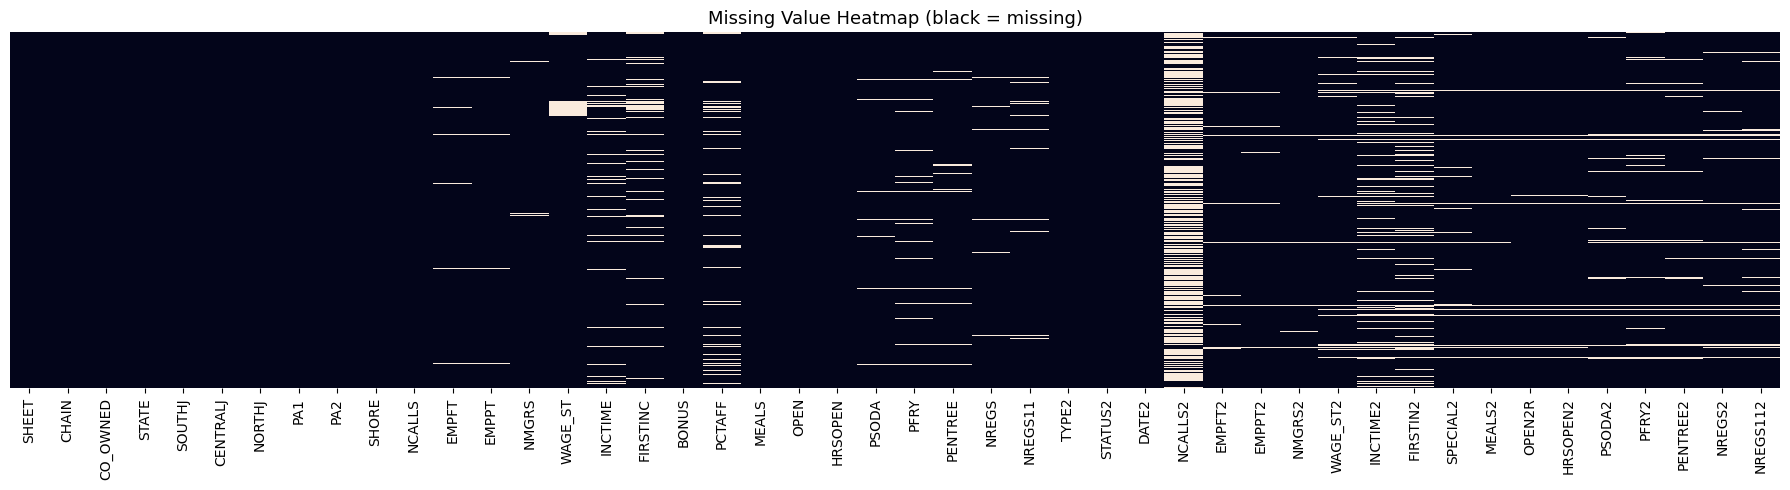

In [11]:
# Heatmap of missingness across all columns
plt.figure(figsize=(18, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Value Heatmap (black = missing)', fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
# Cross-tabulate STATUS2 against Wave 2 employment missingness
pd.crosstab(df['STATUS2'], df['EMPFT2'].isnull(), margins=True)

EMPFT2,False,True,All
STATUS2,,,
0,0,1,1
1,392,7,399
2,0,2,2
3,6,0,6
4,0,1,1
5,0,1,1
All,398,12,410


In [14]:
# Overall missingness rate across all columns
total_cells   = df.shape[0] * df.shape[1]
missing_cells = df.isnull().sum().sum()
print(f'Overall missingness: {missing_cells}/{total_cells} cells = {missing_cells/total_cells*100:.2f}%')

# Wave 1 vs Wave 2 column groups
wave1_cols = ['EMPFT','EMPPT','NMGRS','WAGE_ST','INCTIME','FIRSTINC','PCTAFF','OPEN','HRSOPEN','PSODA','PFRY','PENTREE']
wave2_cols = ['EMPFT2','EMPPT2','NMGRS2','WAGE_ST2','INCTIME2','FIRSTIN2','OPEN2R','HRSOPEN2','PSODA2','PFRY2','PENTREE2']

print(f'\nWave 1 missing cells: {df[wave1_cols].isnull().sum().sum()}')
print(f'Wave 2 missing cells: {df[wave2_cols].isnull().sum().sum()}')

Overall missingness: 827/18860 cells = 4.38%

Wave 1 missing cells: 191
Wave 2 missing cells: 291


In [15]:
# Retain full dataset; create analysis subset for Wave 2 comparisons
df_complete = df[df['STATUS2'] == 1].copy()
print(f'Full dataset:      {len(df)} stores')
print(f'Analysis subset:   {len(df_complete)} stores (STATUS2 == 1, answered Wave 2)')
print(f'Excluded:          {len(df) - len(df_complete)} stores (closed / refused / renovation)')

Full dataset:      410 stores
Analysis subset:   399 stores (STATUS2 == 1, answered Wave 2)
Excluded:          11 stores (closed / refused / renovation)


If stores closed we can't compare employment records, so should be noted and not brought into the dataframe of stores that completed both surveys. Because we are dropping based on this (STATUS2 != 1), dropna is not used. This means this is MAR, with values missing conditional on an observed variable (STATUS2).

### Exploratory Data Analysis (EDA) as Visual Forensics

#### The Univariate Distribution

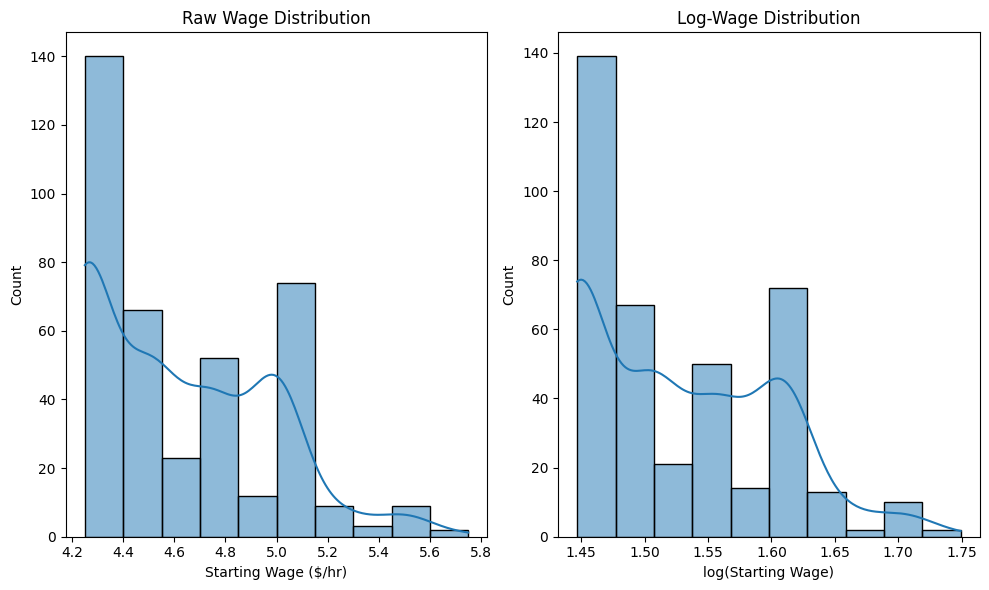

In [25]:
# Visualizing the log-transformation
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['WAGE_ST'].dropna(), kde=True)
plt.title("Raw Wage Distribution")
plt.xlabel("Starting Wage ($/hr)")

plt.subplot(1, 2, 2)
sns.histplot(np.log(df['WAGE_ST'].dropna()), kde=True)
plt.title("Log-Wage Distribution")
plt.xlabel("log(Starting Wage)")

plt.tight_layout()
plt.show()

#### The Bivariate Relationship

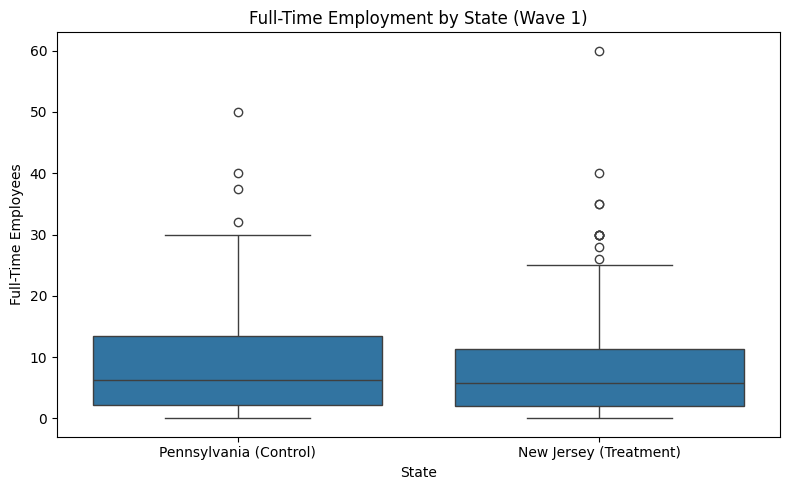

In [26]:
# Binary treatment (STATE) vs full-time employment — box plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='STATE', y='EMPFT', data=df)
plt.xticks([0, 1], ['Pennsylvania (Control)', 'New Jersey (Treatment)'])
plt.title("Full-Time Employment by State (Wave 1)")
plt.xlabel("State")
plt.ylabel("Full-Time Employees")

plt.tight_layout()
plt.show()

#### Outlier Detection

In [29]:
# Manual Tukey Fence implementation (Wave 1)
Q1 = df['EMPFT'].quantile(0.25)
Q3 = df['EMPFT'].quantile(0.75)

IQR = Q3 - Q1

outliers = df[(df['EMPFT'] < (Q1 - 1.5 * IQR)) | (df['EMPFT'] > (Q3 + 1.5 * IQR))]

print(f'Q1: {Q1},  Q3: {Q3},  IQR: {IQR}')
print(f'Lower fence: {Q1 - 1.5 * IQR:.2f},  Upper fence: {Q3 + 1.5 * IQR:.2f}')
print(f'Outliers detected: {len(outliers)} stores')
outliers[['SHEET','STATE','EMPFT','EMPPT','NMGRS','WAGE_ST']]

Q1: 2.0,  Q3: 12.0,  IQR: 10.0
Lower fence: -13.00,  Upper fence: 27.00
Outliers detected: 17 stores


,SHEET,STATE,EMPFT,EMPPT,NMGRS,WAGE_ST
0,46,0,30.0,15.0,3.0,NaN
6,445,0,50.0,35.0,3.0,5.00
11,468,0,40.0,30.0,3.0,5.00
37,57,0,30.0,10.0,3.0,4.67
49,441,0,30.0,10.0,3.0,4.25
60,472,0,37.5,2.0,3.0,4.25
65,478,0,32.0,25.0,4.0,4.50
85,191,1,30.0,20.0,4.0,NaN
98,26,1,30.0,15.0,4.0,5.56
124,152,1,35.0,15.0,4.0,5.12


In [32]:
# Manual Tukey Fence — Wave 2
Q1 = df['EMPFT2'].quantile(0.25)
Q3 = df['EMPFT2'].quantile(0.75)
IQR = Q3 - Q1

outliers_w2 = df[(df['EMPFT2'] < (Q1 - 1.5 * IQR)) | (df['EMPFT2'] > (Q3 + 1.5 * IQR))]

print(f'Wave 2 — Q1: {Q1},  Q3: {Q3},  IQR: {IQR}')
print(f'Lower fence: {Q1 - 1.5 * IQR:.2f},  Upper fence: {Q3 + 1.5 * IQR:.2f}')
print(f'Outliers detected: {len(outliers_w2)} stores')
outliers_w2[['SHEET','STATE','EMPFT2','EMPPT2','NMGRS2','WAGE_ST2']]

Wave 2 — Q1: 2.0,  Q3: 12.0,  IQR: 10.0
Lower fence: -13.00,  Upper fence: 27.00
Outliers detected: 12 stores


,SHEET,STATE,EMPFT2,EMPPT2,NMGRS2,WAGE_ST2
4,61,0,28.0,3.0,6.0,4.75
55,450,0,27.5,8.0,3.0,4.75
71,501,0,30.0,15.0,6.0,4.75
72,503,0,35.0,6.5,3.0,4.50
88,254,1,28.0,10.0,3.0,5.25
92,311,1,35.0,30.0,3.0,5.05
95,372,1,30.0,20.0,5.0,5.05
203,71,1,29.0,14.0,3.0,5.05
220,99,1,30.0,50.0,4.0,5.05
246,142,1,40.0,31.0,5.0,5.05


##### No glaring errors, all changes seem within reason and lining up with the hypothesis noted in the paper. Locations see a reasonable number of employees and have no signs of data input errors.